# Code for plots Fig. 3

In [1]:
# import libraries
import numpy as np
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import scipy.sparse
import cv2
import glob
from skimage import io
import os,sys,inspect
import tifffile as tif
from skimage import measure
import matplotlib.font_manager as fm
from matplotlib.colors import CSS4_COLORS
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

#  importing caiman libraries
import caiman as cm
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import cnmf as cnmf
from caiman.source_extraction.cnmf import params as params
from caiman.summary_images import local_correlations_movie_offline

try:
    cv2.setNumThreads(0)
except:
    pass

try:
    if __IPYTHON__:
        # this is used for debugging purposes only. allows to reload classes
        # when changed
        get_ipython().magic('load_ext autoreload')
        get_ipython().magic('autoreload 2')
except NameError:
    pass

# import modules
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)

from data_import import Aligned_trialtensor_data
from utilities import correct_line_shift_stack, get_shape_parameters



Calling behaviour_import.py from module script:  data_import.behaviour_import
Please enter DataJoint username: root
Please enter DataJoint password: ········
Connecting root@localhost:3306
Calling recording_import.py from module script:  data_import.recording_import
Calling helper_data.py from module script:  utilities.helper_data
Calling helper_tensor.py from module script:  utilities.helper_tensor
Calling helper_logreg.py from module script:  utilities.helper_logreg
Calling aligned_recording.py from module script:  data_import.aligned_recording
Calling validation_alignment.py from module script:  data_import.cell_registration
Calling cell_registration.py from module script:  data_import.cell_registration
CALLING dlc_video.py from module script:  data_import.dlc_video
Calling training.py from module script:  behaviour.training
Calling day_statistics.py from module script:  behaviour.day_statistics
Calling categories.py from module script:  design.categories
Calling helper_design.py fr

## Fig. 3A
Corresponds to histology slice stains

## Fig. 3B
### Example cell segmentation extraction

In [2]:
## run motion correction and extraction following CaImAn pipeline 
# https://github.com/flatironinstitute/CaImAn/tree/main
scan_file = '/home/lsainz/DeepCAD-RT/DeepCAD_RT_pytorch/results/DataFolderIs_documentation_202403092152_ModelFolderIs_train_202211011524/E_10_Iter_2032/2022-06-10_Hippocampus_1_CA1_BK4727-LR_24_0002_E_10_Iter_2032_output.tif'

stack = io.imread(scan_file)
print(stack.shape)


#%% extract scan parameters
current_folder = os.path.dirname(scan_file)

## keep track of all files to delete
temp_files = list()
    
# correct stack for inadvertent line shihfts in each scan direction
stack = correct_line_shift_stack(stack, crop_left=0, crop_right=0)
    
new_path = os.path.splitext(scan_file)[0] + '_corrected.tif'  # avoid overwriting
tif.imwrite(new_path, data=stack)
fnames = [new_path]
temp_files.append(new_path)
        
# (if a cluster already exists terminate it)
if 'dview' in locals():
    cm.stop_server(dview=dview)
    dview.terminate()
        
## start a cluster for parallel processing
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=1, single_thread=True)
        
## get parameters for motion correction
mc_dict = {'fnames': fnames,
            'fr': 30,
            'decay_time': 0.3, 
            'dxy':(2.,2.),
            'pw_rigid': 1,
            'max_shifts': (60,60),
            'strides':(50,50),
            'overlaps': (24,24),
            'max_deviation_rigid':3,
            'border_nan':'copy'
        }  

opts = params.CNMFParams(params_dict=mc_dict)
    
##  MOTION CORRECTION
print('Motion correction in process')
# first we create a motion correction object with the specified parameters
mc = MotionCorrect(fnames, dview=dview, **opts.get_group('motion'))
# note that the file is not loaded in memory
    
## Run motion correction using NoRMCorre
mc.motion_correct(save_movie=True)

print('Finished motion correction')

border_to_0 = 0 if mc.border_nan == 'copy' else mc.border_to_0
# you can include the boundaries of the FOV if you used the 'copy' option
# during motion correction, although be careful about the components near
# the boundaries

# memory map the file in order 'C'
fname_new = cm.save_memmap(mc.mmap_file, base_name='memmap_', order='C',
                           border_to_0=border_to_0)  # exclude borders
    
## Motion correction results
shifts = np.array( mc.shifts_rig ).T 
template = mc.total_template_rig

# save template
template_file = current_folder + '/demo_documentation'
np.save(template_file + '.npy',template)

## now load the file
print('load the file')
Yr, dims, T = cm.load_memmap(fname_new)
images = np.reshape(Yr.T, [T] + list(dims), order='F')
# load frames in python format (T x X x Y)

## restart cluster to clean up memory
print('restart cluster')
cm.stop_server(dview=dview)
n_processes = 1
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=n_processes, single_thread=True)

# parameters for segmentation and  source extraction
print('parameters segmentation')
opts_dict = {
            'fnames': fnames,
            'p': 1,
            'fr': 30,
            'nb': 2,
            'rf': 60,
            'K': 36,
            'gSig': [12, 12],
            'stride': 15,
            'method_init': 'greedy_roi',
            'rolling_sum': True,
            'merge_thr': 0.85,
            'n_processes': 1,
            'only_init': True,
            'ssub': 1,
            'tsub': 1}
 
opts.change_params(params_dict=opts_dict);
    
# RUN CNMF ON PATCHES
# First extract spatial and temporal components on patches and combine them
# for this step deconvolution is turned off (p=0). If you want to have
# deconvolution within each patch change params.patch['p_patch'] to a
# nonzero value
print('Segmentation in process')
opts.change_params({'p': 0})
cnm = cnmf.CNMF(n_processes, params=opts, dview=dview) # dview = dview
cnm = cnm.fit(images)

# plot contours of found components
Cns = local_correlations_movie_offline(mc.mmap_file[0],
                                       remove_baseline=True, window=1000, stride=1000,
                                       winSize_baseline=100, quantil_min_baseline=10,
                                       dview=dview)
Cn = Cns.max(axis=0)
Cn[np.isnan(Cn)] = 0

# RE-RUN seeded CNMF on accepted patches to refine and perform deconvolution
print('Refit segmentation in process')
cnm.params.set('temporal', {'p':1})
cnm2 = cnm.refit(images, dview=dview)

## COMPONENT EVALUATION
print('evaluate components')
eval_dict = {
            'decay_time': 0.3,
            'min_SNR': 3.5,
            'rval_thr': 0.85,
            'use_cnn': True,
            'min_cnn_thr': 0.99,
            'cnn_lowest': 0.1}

cnm2.params.set('quality', eval_dict)
cnm2.estimates.evaluate_components(images, cnm2.params, dview=dview)

## Extract DF/F values
print('extract traces')
cnm2.estimates.detrend_df_f(quantileMin=8, frames_window=800) 
cnm2.estimates.Cn = Cn

## save caiman segmentation results in variables
masks = cnm2.estimates.A   # (flattened_index, nr_masks)

spatial_file = current_folder + '/demo_documentation'
scipy.sparse.save_npz(spatial_file + '.npz',masks)

nr_masks = masks.shape[1]

accepted_masks = np.zeros( nr_masks )
accepted_masks[ cnm2.estimates.idx_components ] = 1

traces = cnm2.estimates.C    # (nr_masks, nr_frames)
dff = cnm2.estimates.F_dff   # (nr_masks, nr_frames)

## delete temporal files
print('deleting temporal files')

log_files = glob.glob('*_LOG_*')
for log_file in log_files:
    os.remove(log_file)
    
search = os.path.join( current_folder, '*_order_C_frames*.mmap' )
temp_C_files = glob.glob(search)
for file in temp_C_files:
    os.remove(file)
    
search = os.path.join( current_folder, '*_order_F_frames*.mmap' )
temp_F_files = glob.glob(search)
for file in temp_F_files:
    os.remove(file)

for file in temp_files:
    os.remove(file)

#STOP CLUSTER 
cm.stop_server(dview=dview)

(2000, 512, 512)
Correcting a shift of  1  pixel.
Motion correction in process
Finished motion correction
load the file
restart cluster
parameters segmentation
Segmentation in process
Refit segmentation in process
evaluate components


USING MODEL:/home/lsainz/caiman_data/model/cnn_model.json
285/285 [==============================] - 0s 2ms/sample
extract traces
deleting temporal files


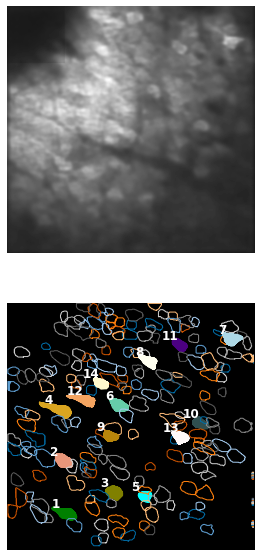

In [3]:
## Plot contours of extracted segmented neuron units and highlight examples
# Select 15 CSS colors
%matplotlib inline
selected_list = np.random.choice(list(CSS4_COLORS),20,replace=False)
selected_colors = {name: CSS4_COLORS[name] for name in selected_list}

# Create a callable list (colormap) from the selected colors
css_colors_cmap = list(selected_colors.values())

selected_idx = [152,134,138,139,145,147,151,154,156,178,186,188,197,283]
rejected_idx = [54,141,143,146,149,177,218,224,250,251,252,257,262,274]

maxs = np.max(dff,axis=1)
sorted_idx = np.argsort(maxs)[::-1]

ref_frame = 893  
ref_array = stack[ref_frame,:,:]

font = fm.FontProperties(weight='bold', size=12)

fig,axs = plt.subplots(2,1)
fig.set_figwidth(5)
fig.set_figheight(10)
# plot real image
axs[0].imshow(ref_array,cmap='gray')
axs[0].axis('off')

centroids = []
bin_arrays = []
axs[1].imshow(np.zeros_like(ref_array),cmap='gray')
k = 1
max_traces = []
for i in range(nr_masks):
    
    pixels = masks[:,i].indices
    weights = masks[:,i].data
    sparse_matrix = scipy.sparse.csc_matrix( (weights, (pixels, np.zeros(len(pixels)) )), shape=(dims[0]*dims[1], 1) )
    mask_array = np.reshape( sparse_matrix.toarray(), dims, order='F' )
    diameter, p, area, compactness = get_shape_parameters(mask_array)
    max_value = np.max(mask_array)
    threshold = 0.3 * max_value
    binarized_mask_array = np.where(mask_array > threshold, 1, 0)
    positions = np.nonzero(binarized_mask_array)
    bin_arrays.append(binarized_mask_array)
    # Find contours at a constant value of 0.9
    contours = measure.find_contours(binarized_mask_array, 0.9)
    accepted = accepted_masks[i]
    centroid = measure.centroid(binarized_mask_array)
    centroids.append(centroid)

    if i in selected_idx:
        for j, contour in enumerate(contours):
            max_traces.append(np.max(dff[i]))
            line = axs[1].plot(positions[1], positions[0], linewidth=1,color=css_colors_cmap[k-1])
            axs[1].text(centroid[1] - 20, centroid[0] - 20, '%i'%k, 
                        horizontalalignment='center', verticalalignment='center',
                        color='white', fontproperties=font)
        k += 1
    elif i not in rejected_idx and accepted:
        for j, contour in enumerate(contours):
            line = axs[1].plot(contour[:, 1], contour[:, 0], linewidth=1)

axs[1].axis('off')
plt.show()

## Fig. 3C
### Example Ca +2 imaging traces

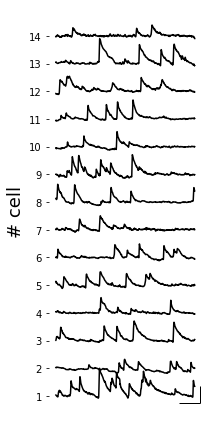

In [4]:
vert_shift = np.max(max_traces)

fig2, axs2 = plt.subplots()
fig2.set_figwidth(3)
fig2.set_figheight(6)
tick_values = []
for l,m in enumerate(selected_idx):
    trace = dff[m] + vert_shift*l + 0.01
    tick_values.append(vert_shift*l + 0.01)
    axs2.plot(trace,color='black')
    
axs2.set_yticks(tick_values) # Set the y-axis tick locations
axs2.set_yticklabels(np.arange(1,k,1)) # Set the y-axis tick labels
axs2.set_ylabel('# cell',fontsize=18)
axs2.spines["top"].set_visible(False)
axs2.spines["right"].set_visible(False)
axs2.spines["bottom"].set_visible(False)
axs2.spines["left"].set_visible(False)
axs2.tick_params(bottom=False,labelbottom=False)

# Create a scale bar for the x-axis
# 10 s -> 30Hz recording
scalebar_x = AnchoredSizeBar(axs2.transData,300, '', 'lower right', 
                              pad=0.1, color='black', frameon=False, 
                              size_vertical=0)


axs2.add_artist(scalebar_x)

# Create a scale bar for the y-axis 30% Delta F/F
scalebar_y = AnchoredSizeBar(axs2.transData,  0.3, '',
                              'lower right', pad=0.1, color='black', 
                              frameon=False, size_vertical=0.3)
axs2.add_artist(scalebar_y)


plt.tight_layout()
plt.show()

## Fig. 3D
### Trial alignment raster plots

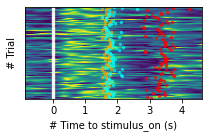

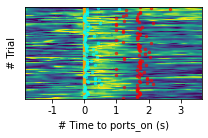

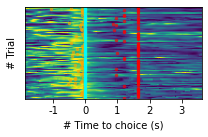

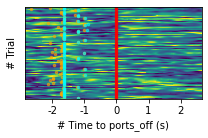

In [5]:
def plot_trials_time_tensor():
    
    mask_id_list = [93,21,545,590] # example single neuron units 
    events = ['stimulus_on','ports_on','choice','ports_off'] # corresponding alignment onsets
    crop_equal = [False,True,True,True]
    
    session = {'name': '1dsc_apr2023',
  'animal_id': 'BK4956_LR',
  'session_id': 28,
  'experimental_timepoint': 'gentest_1',
  'trace_type': 'dff'}
    
    events_toplot = [1,3,0,4] # event timestamps index in entry
    colors_events = ['white','orange','cyan','red']
    

    nr_timepoints_all = 165
    nr_trials_all = 86
    for j,mask_id in enumerate(mask_id_list):
        tensor_entry = Aligned_trialtensor_data() & session \
            & 'event_to_align="%s"'%events[j]

        tensor_activity = np.array(tensor_entry.fetch('tensor_data')[0])
        mask_ids,trial_ids,timepoints = tensor_entry.fetch('tensor_dim_values')[0]
        nr_masks,nr_trials,_ = np.array(tensor_activity).shape
        event_timestamps = tensor_entry.fetch('event_timestamps')[0]
        mask_idx = list(mask_ids).index(mask_id)
        if crop_equal[j]:
            crop_point = int((len(timepoints)-nr_timepoints_all)/2)
            tensor_array = tensor_activity[mask_idx,:nr_trials_all,crop_point:crop_point+nr_timepoints_all]
        else:
            crop_point = len(timepoints)-nr_timepoints_all
            tensor_array = tensor_activity[mask_idx,:nr_trials_all,:-crop_point]

        #normalize range for each trial for heatmap plotting
        maxs = []
        for tr in range(len(tensor_array)):
            trial_activity = tensor_array[tr]
            ran = np.nanmax(trial_activity)-np.nanmin(trial_activity)
            tensor_array[tr] = (trial_activity-np.nanmin(trial_activity))/ran
            maxs.append(np.argmax(trial_activity))

        fig, axs = plt.subplots()
        fig.set_figwidth(3)
        fig.set_figheight(6)
        axs.imshow(tensor_array)
        axs.set_yticks([])
        axs.set_ylabel('# Trial')
        axs.set_xlabel('# Time to %s (s)'%events[j])
        ref_idx =0

        for k,e in enumerate(events_toplot):
            event = event_timestamps[e][:nr_trials_all]

            try:
                event_idx = [np.where(timepoints>t)[0][0] for t in event]
                axs.scatter(event_idx,list(np.arange(0,len(event),1)),
                            c=colors_events[k], alpha=0.6, s=6,label=events[k])
                if event[0]==0:
                    ref_idx=event_idx[0]
            except IndexError:
                pass

        nr_left_labels = int(ref_idx/30) # 30Hz - 30fps 
        nr_right_labels = int((nr_timepoints_all-ref_idx)/30)
        left_labels = list(np.arange(0,-(nr_left_labels+1)*30,-30)/30)
        left_labels.reverse()
        right_labels = list(np.arange(0,(nr_right_labels+1)*30,30)/30)[1:]
        left_ticks = list(np.arange(ref_idx,ref_idx-(nr_left_labels+1)*30,-30))
        left_ticks.reverse()
        right_ticks = list(np.arange(ref_idx,ref_idx +(nr_right_labels+1)*30,30))[1:]
        xticks = left_ticks + right_ticks
        axs.set_xticks(xticks)
        xtick_labels = left_labels + right_labels
        xtick_labels = [str(int(label)) for label in xtick_labels]
        axs.set_xticklabels(xtick_labels)

        plt.tight_layout()
        plt.show()

plot_trials_time_tensor()